<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/CNN_Vehicle_Verification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow
!pip install keras
!pip-install opencv-python
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install mlflow
!pip install albumentations
!pip install kaggle

/bin/bash: line 1: pip-install: command not found
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.1/892.1 kB 46.2 MB/s eta 0

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

folders = [
    'data/raw',
    'data/processed',
    'data/train',
    'data/validation',
    'data/test',
    'models',
    'logs',
    'outputs',
    'saved_models',
    'reports',
    'mlruns',
    'src'
]

In [4]:
for folder in folders:
  os.makedirs(folder, exist_ok=True)

print('Folders Created Successfully!')

Folders Created Successfully!


In [5]:
from google.colab import files
files.upload()

Saving kaggle (5).json to kaggle (5).json


{'kaggle (5).json': b'{"username":"pranay061020","key":"5bd1a589e8c2159e9090b6ca8df83d78"}'}

In [7]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [8]:
!kaggle datasets download -d marquis03/vehicle-classification

Dataset URL: https://www.kaggle.com/datasets/marquis03/vehicle-classification
License(s): apache-2.0
100% 914M/914M [00:12<00:00, 77.8MB/s]



In [9]:
import zipfile

with zipfile.ZipFile('/content/vehicle-classification.zip','r') as zip_ref:
  zip_ref.extractall('data/raw')

print('Data Extracted Successfully!')

Data Extracted Successfully!


In [10]:
import os

base_path = 'data/raw'

print(os.listdir(base_path))

['train', 'val', 'test']


In [11]:
classes = os.listdir(base_path)

for cls in classes:
  path = os.path.join(base_path,cls)

  print(cls,len(os.listdir(path)))

train 10
val 10
test 200


data/raw/train/truck
Could not read image: data/raw/train/truck
data/raw/val/heavy truck
Could not read image: data/raw/val/heavy truck
data/raw/test/2aeb7856890c8dc0e0b311077d386690.jpg


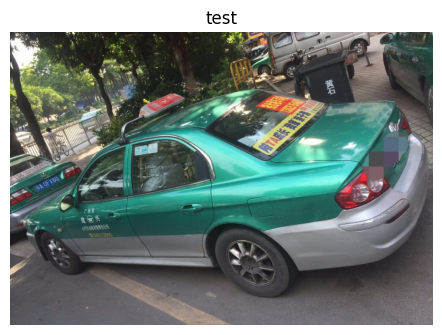

In [14]:
import os
import cv2
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

for i, cls in enumerate(classes):

    class_path = os.path.join(base_path, cls)

    img_name = random.choice(os.listdir(class_path))

    img_path = os.path.join(class_path, img_name)

    print(img_path)   # check image path

    img = cv2.imread(img_path)

    if img is None:
        print(f"Could not read image: {img_path}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

data/raw/train/bus
Could not read image: data/raw/train/bus
data/raw/val/SUV
Could not read image: data/raw/val/SUV
data/raw/test/f0a70d450423aa8c88d87a0a0c9c1acf.jpg


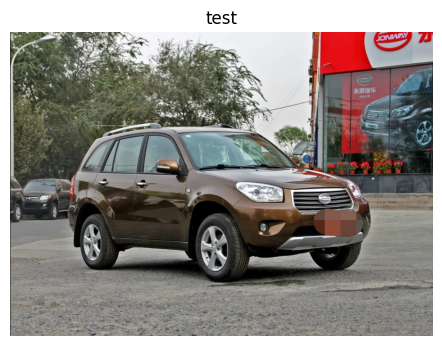

In [15]:
import os
import cv2
import random
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

for i, cls in enumerate(classes):

    class_path = os.path.join(base_path, cls)

    img_name = random.choice(os.listdir(class_path))

    img_path = os.path.join(class_path, img_name)

    print(img_path)   # check image path

    img = cv2.imread(img_path)

    if img is None:
        print(f"Could not read image: {img_path}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.show()

In [18]:
import numpy as np

IMG_SIZE = 128

X = []
y = []

for label, category in enumerate(classes):

    category_path = os.path.join(base_path, category)

    print(f"Loading {category}")

    for image_name in os.listdir(category_path):

        image_path = os.path.join(category_path, image_name)

        try:

            img = cv2.imread(image_path)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            img = img / 255.0

            X.append(img)

            y.append(label)

        except Exception as e:
            print(image_path)
            print(e)

Loading train
Loading val
Loading test


In [19]:
import numpy as np

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(200, 128, 128, 3)
(200,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [22]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(256, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(4, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,956 (24.86 MB)

 Trainable params: 6,517,508 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [24]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
num_classes = len(classes)

In [28]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(num_classes, activation='softmax'))

In [29]:
print(y_train.shape)

(160, 3)


In [30]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)